# Стэкинг (Stacking)

В этом ноутбуке разбираются:

1. Что такое стэкинг и чем он отличается от бэггинга и бустинга.
2. Почему для стэкинга критично важны **out-of-fold (OOF)**
   предсказания базовых моделей — и что будет, если про это забыть.
3. `StackingClassifier`/`StackingRegressor` в scikit-learn (и для
   сравнения — `VotingClassifier`): параметры, методы.
4. Основные преимущества и ограничения подхода.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import modules.plots as mplts
import modules.style as style

from sklearn.datasets import make_classification, load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    StackingClassifier, VotingClassifier,
)

sns.set_style("whitegrid")
%matplotlib inline

## 1. Что такое стэкинг

И бэггинг, и бустинг комбинируют предсказания **однотипных** базовых
моделей (обычно деревьев) по **фиксированному** правилу — усреднение
или взвешенное голосование с весами, заданными самим алгоритмом
обучения (например, $\alpha_m$ в AdaBoost).

**Стэкинг (stacking, stacked generalization)** устроен иначе:

1. Берётся набор **разнородных** базовых моделей уровня 0
   ("level-0" / базовые модели) $h_1, \dots, h_K$ — например,
   логистическая регрессия, случайный лес и метод опорных векторов
   одновременно. Разные модели имеют разную природу ошибок (разный
   bias/variance, разную чувствительность к признакам) — это
   специально используемое разнообразие.
2. Предсказания всех базовых моделей на каждом объекте становятся
   **новыми признаками** ("мета-признаками"):
   $$
   z_i = \big(h_1(x_i),\, h_2(x_i),\, \dots,\, h_K(x_i)\big) \in \mathbb{R}^{K}.
   $$
3. На этих мета-признаках обучается ещё одна модель — **мета-модель**
   уровня 1 ("final estimator") $g$, которая учится, *как лучше всего*
   скомбинировать прогнозы базовых моделей:
   $$
   \hat y(x) = g\big(h_1(x), \dots, h_K(x)\big) = g(z).
   $$

Это стоит явно сравнить с простым голосованием/усреднением (`voting`,
как в бэггинге): там комбинация — **фиксированная линейная функция с
заранее заданными (обычно равными) весами**,
$\hat y_{\text{voting}}(x) = \sum_{k=1}^{K} w_k\, h_k(x)$ с
фиксированными $w_k$ (например, $w_k = 1/K$). В стэкинге же функция
$g$ **обучается по данным** — она может придать разным моделям разный
(и заранее неизвестный) вес, а если $g$ нелинейна (например,
градиентный бустинг в роли мета-модели), то и вовсе комбинировать
базовые модели по-разному в разных областях пространства признаков.

Ниже — схема архитектуры: несколько базовых моделей получают на вход
одни и те же исходные признаки, их прогнозы объединяются в новый набор
признаков $z$, на котором уже обучается мета-модель $g$.

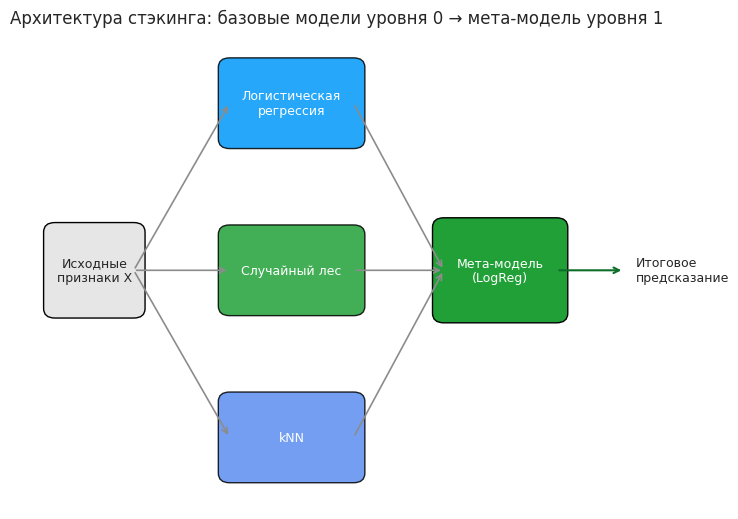

In [2]:
mplts.plot_stacking_architecture(
    ["Логистическая\nрегрессия", "Случайный лес", "kNN"],
    meta_name="Мета-модель\n(LogReg)"
)
plt.show()

## 2. Ключевой момент: out-of-fold (OOF) предсказания

Есть соблазн реализовать шаг 2 наивно: обучить базовые модели на
`X_train`, тут же получить их предсказания на этом же `X_train` и
использовать эти предсказания как мета-признаки для обучения
мета-модели. **Так делать нельзя.**

Проблема в том, что базовые модели (особенно склонные к переобучению —
например, `kNN` с `n_neighbors=1` или глубокое дерево) могут почти
идеально "предсказать" свою же обучающую выборку — просто её запомнив,
а не выучив реальную закономерность. Если скормить мета-модели такие
слишком оптимистичные, "подсмотренные" прогнозы, она решит, что такой
базовой модели можно доверять почти полностью — и придаст ей завышенный
вес, хотя на новых данных эта модель может работать заметно хуже.

Правильный способ — как и в кросс-валидации: для каждого объекта
брать прогноз базовой модели, полученный **на блоке, в который этот
объект не входил при обучении** — то есть **out-of-fold (OOF)**
предсказание. Формально: разобьём индексы обучающей выборки на $J$
блоков $D^{(1)}, \dots, D^{(J)}$ (как в кросс-валидации). Для каждого
блока $j$ обучим копию базовой модели $h_k^{(-j)}$ **без** этого блока
— на $D_{\text{train}} \setminus D^{(j)}$ — и определим OOF-прогноз
для любого объекта $x_i \in D^{(j)}$ как прогноз именно этой,
"не видевшей" его модели:

$$
\hat h_k^{\text{OOF}}(x_i) = h_k^{(-j(i))}(x_i), \qquad \text{где } j(i)
\text{ — номер блока, куда попал объект } i.
$$

Мета-признаки для обучения $g$ строятся именно из OOF-прогнозов:
$z_i = \big(\hat h_1^{\text{OOF}}(x_i), \dots, \hat h_K^{\text{OOF}}(x_i)\big)$
— то есть та же идея, что и OOB-оценка в ноутбуке про бэггинг: прогноз
объекта должен исходить только от моделей, которые его не видели.
Именно так внутри работает `StackingClassifier`/`StackingRegressor` в
scikit-learn — параметр `cv` задаёт схему кросс-валидации для генерации
OOF-предсказаний, ровно как в `cross_val_predict`. (При инференсе на
новых данных используются уже финальные версии $h_k$, дообученные на
**всей** `X_train` — см. `.estimators_` ниже.)

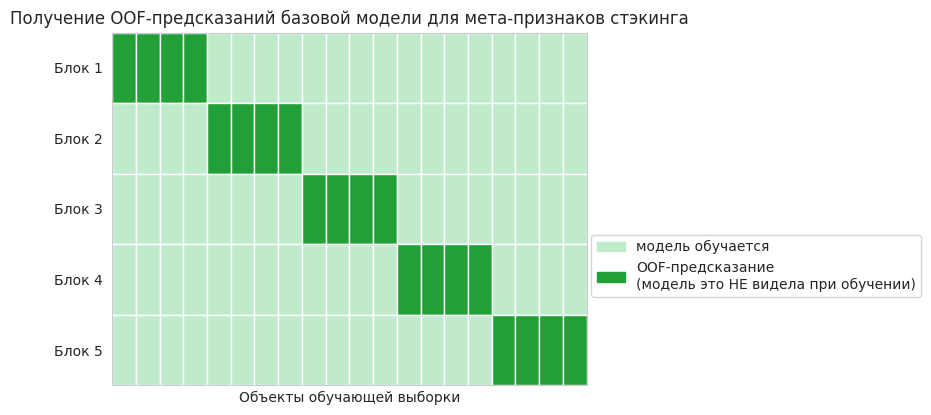

In [3]:
mplts.plot_oof_scheme(n_folds=5, n_samples=20)
plt.show()

Проверим на практике, что даёт наивный (некорректный) подход в
сравнении с честным OOF-стэкингом. Возьмём намеренно переобучающийся
базовый алгоритм — `kNN` с одним соседом (`n_neighbors=1`), который по
построению даёт 100% точность на своей же обучающей выборке (каждый
объект — ближайший сосед самому себе).

In [4]:
X, y = make_classification(n_samples=600, n_features=20, n_informative=8,
                            n_redundant=4, flip_y=0.05, class_sep=0.8, random_state=0)
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)

base_models = [
    ("logreg", LogisticRegression(max_iter=1000)),
    ("knn1", KNeighborsClassifier(n_neighbors=1)),
    ("rf", RandomForestClassifier(n_estimators=200, random_state=0)),
]

for name, m in base_models:
    m.fit(X_train, y_train)
    print(f"{name:8s}: train accuracy = {m.score(X_train, y_train):.3f}, "
          f"test accuracy = {m.score(X_test, y_test):.3f}")

logreg  : train accuracy = 0.871, test accuracy = 0.900
knn1    : train accuracy = 1.000, test accuracy = 0.867
rf      : train accuracy = 1.000, test accuracy = 0.893


In [5]:
# Наивный (некорректный) стэкинг — мета-признаки строятся из
# предсказаний, полученных на ТОЙ ЖЕ выборке, на которой модели обучены.
meta_train_naive = np.column_stack([m.predict_proba(X_train)[:, 1] for _, m in base_models])
meta_test = np.column_stack([m.predict_proba(X_test)[:, 1] for _, m in base_models])

meta_naive = LogisticRegression().fit(meta_train_naive, y_train)
print("Наивный (in-sample) стэкинг — test accuracy:",
      round(meta_naive.score(meta_test, y_test), 3))
print("Веса, которые мета-модель придала базовым моделям "
      "[logreg, knn1, rf]:", np.round(meta_naive.coef_[0], 2))

# Честный стэкинг с OOF-предсказаниями (встроенный механизм sklearn, cv=5)
stack = StackingClassifier(estimators=base_models, final_estimator=LogisticRegression(),
                            cv=5)
stack.fit(X_train, y_train)
print("\nКорректный OOF-стэкинг (StackingClassifier, cv=5) — test accuracy:",
      round(stack.score(X_test, y_test), 3))
print("Веса, которые мета-модель придала базовым моделям "
      "[logreg, knn1, rf]:", np.round(stack.final_estimator_.coef_[0], 2))

Наивный (in-sample) стэкинг — test accuracy: 0.867
Веса, которые мета-модель придала базовым моделям [logreg, knn1, rf]: [1.25 4.6  3.31]

Корректный OOF-стэкинг (StackingClassifier, cv=5) — test accuracy: 0.887
Веса, которые мета-модель придала базовым моделям [logreg, knn1, rf]: [1.98 2.13 2.94]


Наивная версия придаёт непропорционально большой вес
переобученному `knn1` (его "идеальные" прогнозы на train выглядят
для мета-модели крайне убедительно, хотя это лишь запоминание), и
итоговое качество на тесте оказывается ниже, чем у честного
OOF-стэкинга, где вклад каждой базовой модели оценён по её реальной
обобщающей способности на данных, которые она не видела при обучении.
Это ровно та ошибка, которую `StackingClassifier` предотвращает
автоматически, если её не обходить вручную.

## 3. `StackingClassifier` / `StackingRegressor` в scikit-learn

**Основные параметры:**
* `estimators` — список пар `(имя, модель)` — базовые модели уровня 0;
* `final_estimator` — мета-модель уровня 1 (по умолчанию —
  `LogisticRegression`/`RidgeCV` для классификации/регрессии
  соответственно); часто её стоит брать **простой и с регуляризацией**
  — мета-признаков немного, и переобучить саму мета-модель тоже
  возможно;
* `cv` — схема кросс-валидации для генерации OOF-предсказаний базовых
  моделей (число блоков, объект-сплиттер типа `StratifiedKFold`, или
  `"prefit"`, если базовые модели уже обучены заранее и переобучать их
  не нужно);
* `stack_method` — какой метод базовой модели использовать для
  получения мета-признаков (`"predict_proba"`, `"decision_function"`,
  `"predict"`; `"auto"` выбирает лучший доступный);
* `passthrough` — если `True`, к мета-признакам (прогнозам базовых
  моделей) дополнительно добавляются и исходные признаки `X` — мета-
  модель тогда видит и "мнения" базовых моделей, и сами данные;
* `n_jobs` — базовые модели на каждом фолде обучаются независимо и
  могут обучаться параллельно.

**После `fit` доступны:** `.estimators_` (базовые модели, дообученные
на всей `X_train`, — именно они используются на инференсе),
`.final_estimator_` (обученная мета-модель), `.predict`,
`.predict_proba`, `.score`.

Для сравнения — `VotingClassifier`/`VotingRegressor`: более простой
способ объединить несколько моделей **без** обучения мета-модели —
либо голосование большинством (`voting="hard"`), либо усреднение
вероятностей (`voting="soft"`, опционально с ручными `weights`).
Никакого OOF-механизма здесь не требуется, так как ничего не
обучается поверх предсказаний — веса либо равны, либо задаются
пользователем заранее, а не выучиваются моделью.

In [6]:
voting = VotingClassifier(estimators=base_models, voting="soft")
voting.fit(X_train, y_train)
print("VotingClassifier (soft) — test accuracy:", round(voting.score(X_test, y_test), 3))

stack_passthrough = StackingClassifier(estimators=base_models,
                                        final_estimator=LogisticRegression(max_iter=1000),
                                        cv=5, passthrough=True)
stack_passthrough.fit(X_train, y_train)
print("StackingClassifier с passthrough=True — test accuracy:",
      round(stack_passthrough.score(X_test, y_test), 3))

VotingClassifier (soft) — test accuracy: 0.887
StackingClassifier с passthrough=True — test accuracy: 0.873


## 4. Преимущества и ограничения стэкинга

### Преимущества

* **Использует разнородность моделей.** В отличие от бэггинга
  (усредняет копии одной и той же модели) и бустинга (последовательно
  наращивает один и тот же тип слабой модели), стэкинг может объединить
  модели с принципиально разной природой ошибок — например, линейную
  модель (хорошо ловит глобальные линейные зависимости) и лес
  (хорошо ловит нелинейные взаимодействия признаков). Чем более
  разнообразны и **менее скоррелированы** ошибки базовых моделей, тем
  больше потенциальный выигрыш — идея та же, что и с корреляцией
  $\rho$ в формуле дисперсии бэггинга, только здесь работает не для
  дисперсии одного типа модели, а для разнообразия самих типов моделей.
* **Мета-модель учит нетривиальную, гибкую комбинацию** — не просто
  средние/равные веса (как в voting без ручных весов), а
  оптимизированную под конкретные данные комбинацию, которая может
  по-разному доверять разным базовым моделям.
* Стэкинг можно применять **многоуровнево** — например, мета-моделью
  первого уровня стэкинга может быть ансамбль (даже другой стэкинг),
  что даёт ещё один уровень комбинирования (на практике редко даёт
  большой выигрыш относительно сложности, но принципиально возможно).

### Ограничения

* **Существенно дороже по вычислениям**, чем одна модель или даже
  простой voting: нужно обучить все базовые модели `cv` раз (для
  генерации OOF-предсказаний) плюс ещё раз на всей обучающей выборке
  (для инференса), плюс обучить саму мета-модель. Время
  обучения/инференса растёт с числом базовых моделей.
* **Риск утечки данных и переобучения мета-модели**, если не соблюдать
  OOF-дисциплину — что было наглядно показано в разделе 2. Даже при
  использовании `StackingClassifier` стоит помнить, что мета-модель
  обучается всего на нескольких (по числу базовых моделей)
  мета-признаках — при малом объёме данных её тоже стоит регуляризовать
  (не брать в качестве неё сложную, легко переобучающуюся модель).
* **Хуже интерпретируется**, чем даже отдельный ансамбль — теперь
  нужно объяснять и предсказания каждой базовой модели, и то, как их
  скомбинировала мета-модель ("чёрный ящик поверх чёрных ящиков").
* **Ограниченная отдача при похожих базовых моделях.** Если все базовые
  модели совершают похожие ошибки (сильно коррелированы), стэкинг не
  даст заметного выигрыша над лучшей из них — как и в бэггинге,
  ключевую роль играет именно разнообразие, а не число моделей.
* **Сложность в продакшене.** Нужно хранить, версионировать и
  поддерживать в согласованном состоянии *все* базовые модели и
  мета-модель одновременно — это больше движущихся частей, больше
  точек отказа и больше задержка на инференсе по сравнению с одной
  моделью или даже с бэггингом/бустингом (где все базовые модели хотя
  бы одного типа).

Ниже — итоговое сравнение: лучшая одиночная базовая модель, простое
голосование (voting) и стэкинг на одних и тех же данных.

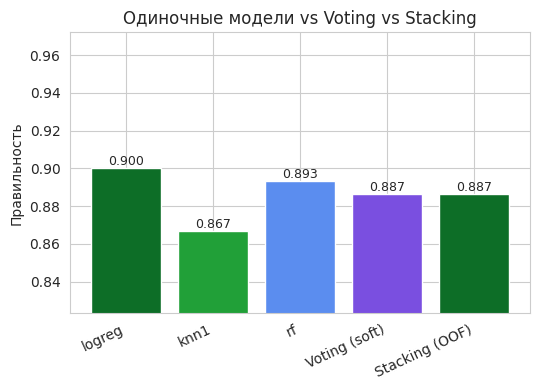

In [7]:
single_scores = {name: m.score(X_test, y_test) for name, m in base_models}
best_single_name = max(single_scores, key=single_scores.get)

comparison_names = list(single_scores.keys()) + ["Voting (soft)", "Stacking (OOF)"]
comparison_scores = list(single_scores.values()) + [
    voting.score(X_test, y_test), stack.score(X_test, y_test)
]

mplts.plot_model_comparison_bars(comparison_names, comparison_scores,
                                  title="Одиночные модели vs Voting vs Stacking")
plt.show()

Обратите внимание: на этом конкретном тестовом разбиении простая
логистическая регрессия сама по себе оказалась не хуже (а по точечной
оценке — даже немного лучше) voting и стэкинга. Это не противоречит
всему сказанному выше, а хорошо иллюстрирует ограничения раздела 4 на
практике: во-первых, оценка на одном тестовом разбиении — шумная
величина (вспомните первый ноутбук про кросс-валидацию — для надёжного
сравнения стоило бы смотреть на разброс по нескольким разбиениям, а не
на одно число); во-вторых, если один из базовых алгоритмов и так
хорошо подходит под задачу, а остальные ошибаются похожим образом
(коррелированы), выигрыш от комбинирования моделей может быть
небольшим или вовсе отсутствовать — стэкинг не гарантирует улучшение
над лучшей отдельной моделью, а лишь даёт основанный на данных способ
попытаться его получить.

### Сводная таблица

| Подход | Как комбинируются модели | Что даёт выигрыш | Основной риск |
|---|---|---|---|
| `VotingClassifier`/`Regressor` | фиксированное голосование/усреднение | простота, без риска утечки | веса не выучиваются (если не заданы вручную) |
| `StackingClassifier`/`Regressor` | обучаемая мета-модель поверх OOF-предсказаний | использует разнородность базовых моделей, выучивает оптимальную комбинацию | дороже по вычислениям, риск утечки при нарушении OOF-схемы, сложнее в проде |
